In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('hr_data.csv')

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
print(df.isnull().sum())
print(df.duplicated().sum())


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [3]:
df.drop(columns=['EmployeeCount','Over18','StandardHours'],inplace=True)
print(df.shape)

(1470, 32)


In [4]:
print(df['Attrition'].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


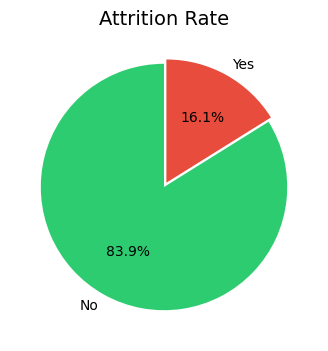

In [5]:
plt.figure(figsize=(6, 4))
colors = ['#2ecc71','#e74c3c']

df['Attrition'].value_counts().plot(
    kind='pie',
    colors=colors,
    startangle=90,
    autopct='%1.1f%%',
    explode=(0,0.04)
)
plt.title('Attrition Rate',fontsize=14)
plt.ylabel('')
plt.show()

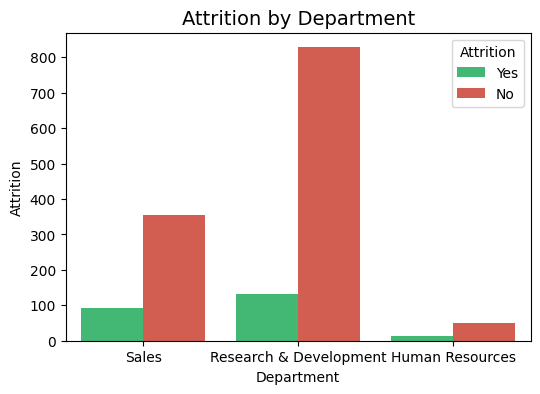

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Department' , hue='Attrition' , palette=['#2ecc71', '#e74c3c'])
plt.title('Attrition by Department',fontsize=14)
plt.xlabel('Department')
plt.ylabel('Attrition')
plt.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_8440\3599438041.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='Age', palette=['#2ecc71', '#e74c3c'])


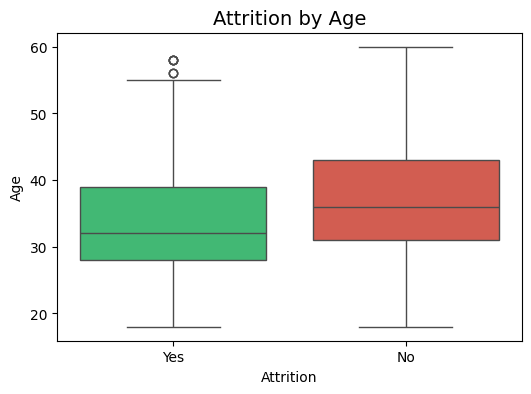

In [7]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Attrition', y='Age', palette=['#2ecc71', '#e74c3c'])
plt.title('Attrition by Age', fontsize=14)
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_8440\3689940862.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df,x='Attrition',y='MonthlyIncome',palette=['#2ecc71', '#e74c3c'])


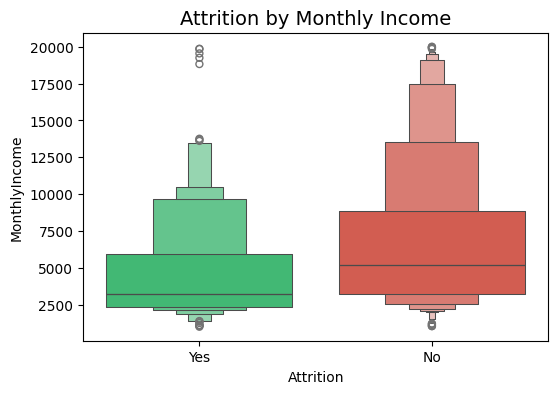

In [8]:
plt.figure(figsize=(6,4))
sns.boxenplot(data=df,x='Attrition',y='MonthlyIncome',palette=['#2ecc71', '#e74c3c'])
plt.title('Attrition by Monthly Income',fontsize=14)
plt.show()

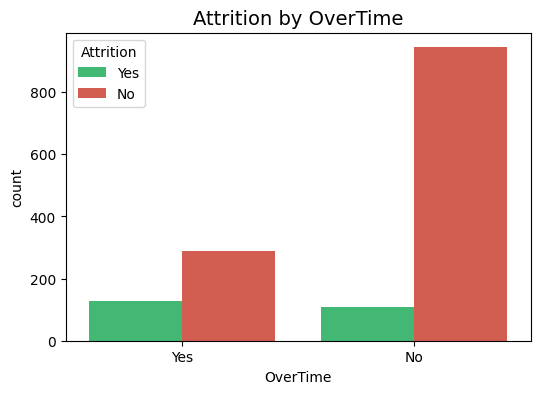

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='OverTime', hue='Attrition', palette=['#2ecc71', '#e74c3c'])
plt.title('Attrition by OverTime', fontsize=14)
plt.show()

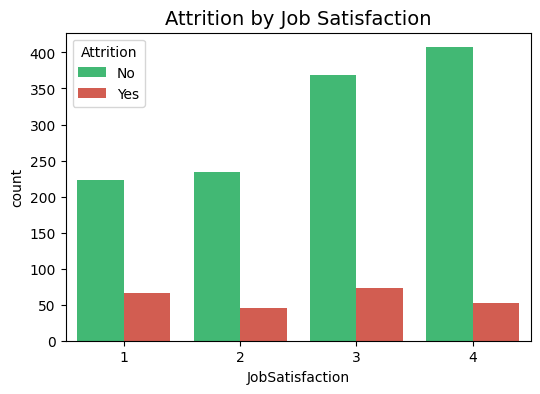

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition', palette=['#2ecc71', '#e74c3c'])
plt.title('Attrition by Job Satisfaction', fontsize=14)
plt.show()

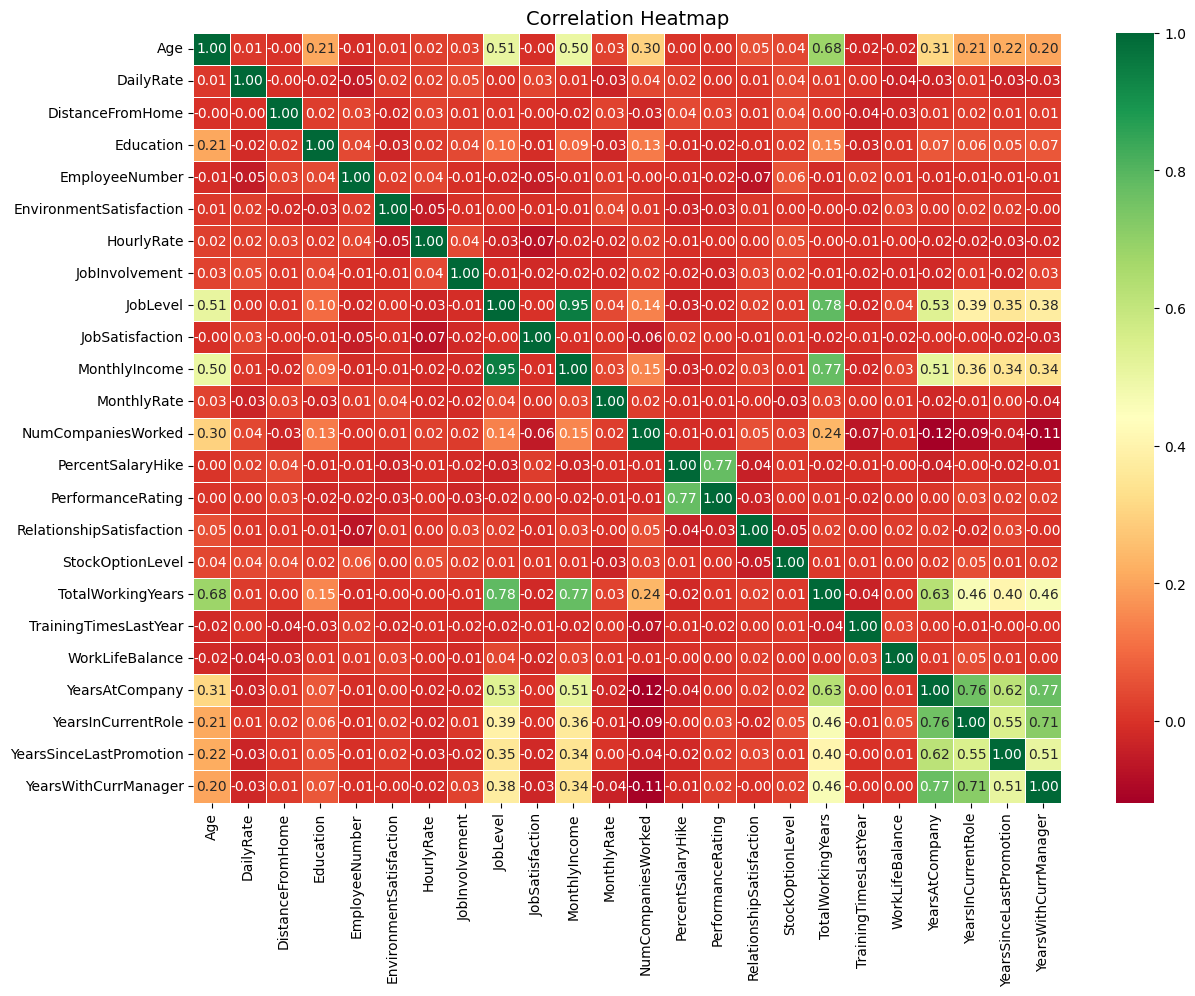

In [10]:

plt.figure(figsize=(14, 10))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5
)
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

In [11]:
print(df.groupby('Department')['Attrition'].value_counts().unstack())


Attrition                No  Yes
Department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92


In [12]:
print("Attrition Rate by Department:")
dept_attrition = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()
print(dept_attrition)

Attrition Rate by Department:
Attrition                     No       Yes
Department                                
Human Resources         0.809524  0.190476
Research & Development  0.861602  0.138398
Sales                   0.793722  0.206278


In [13]:
print("Average Monthly Income:")
print(df.groupby('Attrition')['MonthlyIncome'].mean())

Average Monthly Income:
Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64


In [14]:
print("Attrition Rate by OverTime:")
print(df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack())

Attrition Rate by OverTime:
Attrition        No       Yes
OverTime                     
No         0.895636  0.104364
Yes        0.694712  0.305288


In [15]:
print("Average Age:")
print(df.groupby('Attrition')['Age'].mean())

Average Age:
Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64


In [16]:
df.to_csv('hr_data_clean.csv', index=False)
print("Data Saved!")

PermissionError: [Errno 13] Permission denied: 'hr_data_clean.csv'

In [17]:
from sqlalchemy import create_engine

engine = create_engine('mssql+pyodbc://DESKTOP-DHLRJPC\\SQLEXPRESS/HR_DB?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes')

df.to_sql('hr_data',engine,if_exists='replace', index=False)
print("Data Uploaded to SQL Server!")

Data Uploaded to SQL Server!
